# HW6 


In [15]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

IN_DIR = 'Input_Images'
OUT_DIR = 'Output_Images'
for p in ['Part_1','Part_2','Part_3','Part_4']:
    os.makedirs(OUT_DIR+'/'+p, exist_ok=True)

pairs = sorted(os.listdir(IN_DIR))
print(pairs)

['Pair1_DogCat', 'Pair2_Bridges']


In [16]:
def load_gray(path):
    im = cv2.imread(path)
    return cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

data = {}
for pair_name in pairs:
    folder = IN_DIR+'/'+pair_name
    files = os.listdir(folder)
    near_file = [f for f in files if f.lower().startswith('near')][0]
    far_file  = [f for f in files if f.lower().startswith('far')][0]
    near = load_gray(folder+'/'+near_file)
    far  = load_gray(folder+'/'+far_file)
    data[pair_name] = {'near': near, 'far': far}
    print(pair_name, 'near:', near.shape, 'far:', far.shape)

Pair1_DogCat near: (361, 410) far: (361, 410)
Pair2_Bridges near: (470, 780) far: (470, 780)


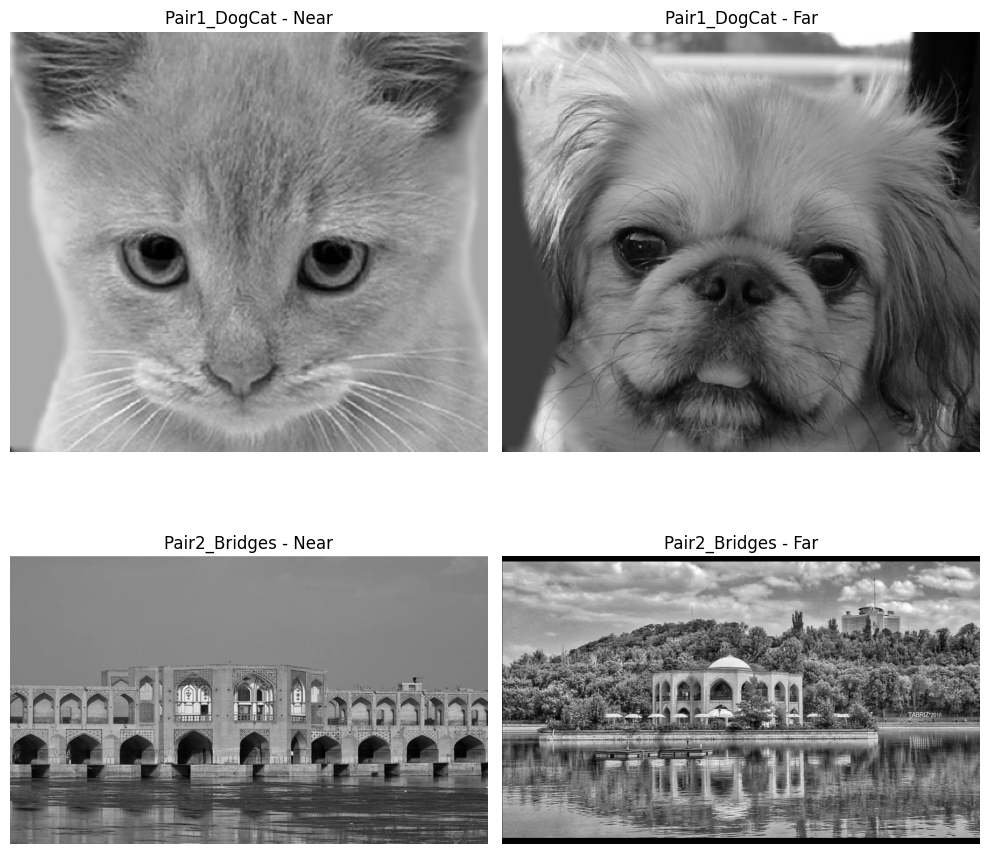

In [17]:
n = len(pairs)
fig, axes = plt.subplots(n, 2, figsize=(10, 5 * n))


if n == 1:
    axes = np.array([axes])

for i, pair_name in enumerate(pairs):
    # Near
    axes[i, 0].imshow(data[pair_name]['near'], cmap='gray')
    axes[i, 0].set_title(f"{pair_name} - Near")
    axes[i, 0].axis('off')
    
    # Far
    axes[i, 1].imshow(data[pair_name]['far'], cmap='gray')
    axes[i, 1].set_title(f"{pair_name} - Far")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right;">
 قسمت ۱ - هرم لاپلاسی ۸ مرحله‌ای
</div>

In [18]:
def gaussian_pyramid(gray, levels=8):
    G = [gray.astype(np.float64)]
    cur = gray.astype(np.float64)
    for i in range(levels-1):
        cur = cv2.pyrDown(cur)
        G.append(cur)
    return G

def laplacian_pyramid(G):

    N = len(G)
    L = []
    for i in range(N-1):
        size = (G[i].shape[1], G[i].shape[0])
        up = cv2.pyrUp(G[i+1], dstsize=size)
        L.append(G[i] - up)
    L.append(G[N-1])
    return L

def reconstruct(L):
    N = len(L)
    R = L[N-1]
    for i in range(N-2, -1, -1):
        size = (L[i].shape[1], L[i].shape[0])
        R = L[i] + cv2.pyrUp(R, dstsize=size)
    return R


test_G = gaussian_pyramid(data['Pair1_DogCat']['near'], 8)
test_L = laplacian_pyramid(test_G)
test_R = reconstruct(test_L)
print('max abs reconstruction error:', np.abs(test_R - data['Pair1_DogCat']['near'].astype(np.float64)).max())

max abs reconstruction error: 0.0


In [ ]:
def lap_to_display(l, is_top):

    if is_top:
        return np.clip(l, 0, 255).astype(np.uint8)
    return np.clip(l+128, 0, 255).astype(np.uint8)

def tile_pyramid(L):
    h = max(l.shape[0] for l in L)
    imgs_disp = [lap_to_display(l, i==len(L)-1) for i,l in enumerate(L)]
    total_w = sum(im.shape[1] for im in imgs_disp) + 10*(len(imgs_disp)-1)
    canvas = np.full((h, total_w), 255, dtype=np.uint8)
    x = 0
    for im in imgs_disp:
        canvas[0:im.shape[0], x:x+im.shape[1]] = im
        x += im.shape[1]+10
    return canvas

pyramids = {}   # (pair, 'near'/'far') -> (G, L)
for pair_name in pairs:
    for role in ['near','far']:
        gray = data[pair_name][role]
        G = gaussian_pyramid(gray, 8)
        L = laplacian_pyramid(G)
        pyramids[(pair_name,role)] = (G, L)
        tiled = tile_pyramid(L)
        cv2.imwrite(f'{OUT_DIR}/Part_1/{pair_name}_{role}_laplacian_pyramid.png', tiled)
        print(pair_name, role, 'sizes:', [g.shape for g in G])

Pair1_DogCat near sizes: [(361, 410), (181, 205), (91, 103), (46, 52), (23, 26), (12, 13), (6, 7), (3, 4)]
Pair1_DogCat far sizes: [(361, 410), (181, 205), (91, 103), (46, 52), (23, 26), (12, 13), (6, 7), (3, 4)]
Pair2_Bridges near sizes: [(470, 780), (235, 390), (118, 195), (59, 98), (30, 49), (15, 25), (8, 13), (4, 7)]
Pair2_Bridges far sizes: [(470, 780), (235, 390), (118, 195), (59, 98), (30, 49), (15, 25), (8, 13), (4, 7)]


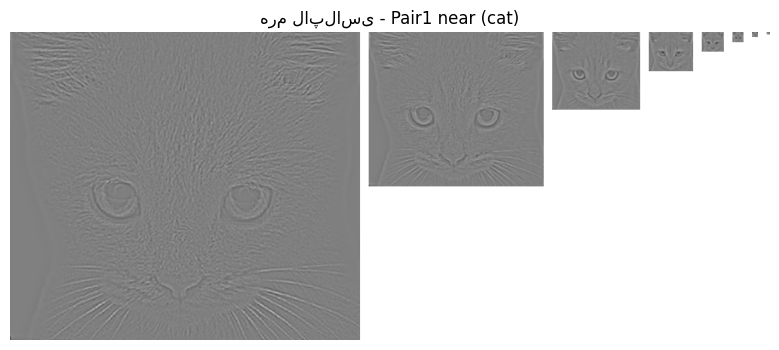

In [20]:
plt.figure(figsize=(14,4))
plt.imshow(cv2.imread(f'{OUT_DIR}/Part_1/Pair1_DogCat_near_laplacian_pyramid.png'), cmap='gray')
plt.axis('off')
plt.title('هرم لاپلاسی - Pair1 near (cat)')
plt.show()


<div dir="rtl" style="text-align: right;">
 قسمت ۲ - تصویر هیبرید: near فرکانس‌بالا + far فرکانس‌پایین
</div>

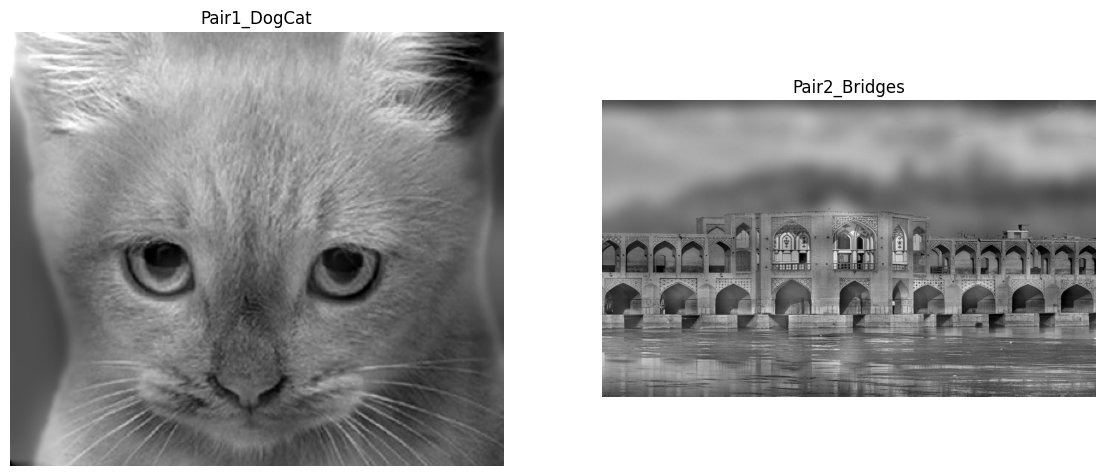

In [31]:
hybrid_p2 = {}
for pair_name in pairs:
    Gn, Ln = pyramids[(pair_name,'near')]
    Gf, Lf = pyramids[(pair_name,'far')]
    L_hybrid = Ln[0:4] + Lf[4:8]
    hybrid = reconstruct(L_hybrid)
    hybrid_u8 = np.clip(hybrid, 0, 255).astype(np.uint8)
    hybrid_p2[pair_name] = hybrid_u8
    cv2.imwrite(f'{OUT_DIR}/Part_2/{pair_name}_hybrid.png', hybrid_u8)

fig, axes = plt.subplots(1, len(pairs), figsize=(7*len(pairs),7))
for ax, pair_name in zip(axes, pairs):
    ax.imshow(hybrid_p2[pair_name], cmap='gray')
    ax.set_title(pair_name)
    ax.axis('off')
plt.show()

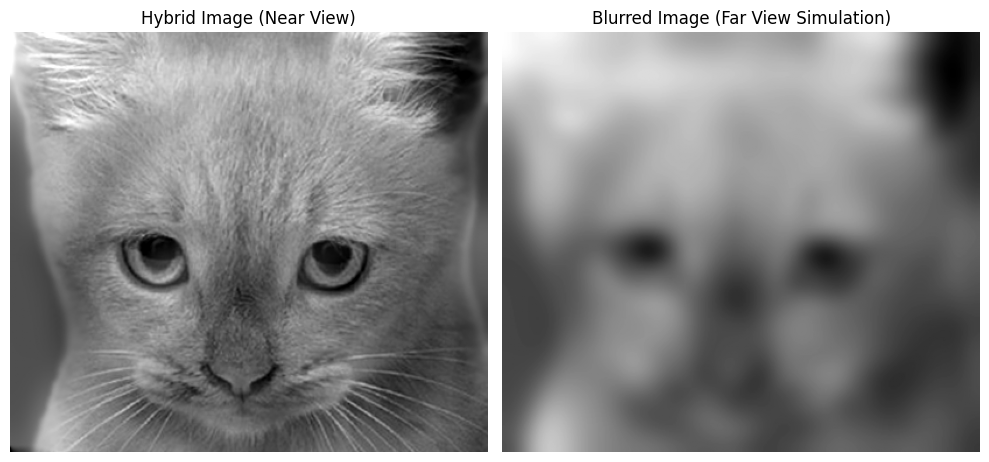

In [22]:
test_im = hybrid_p2['Pair1_DogCat']
blurred = cv2.GaussianBlur(test_im, (0, 0), sigmaX=10)

plt.figure(figsize=(10, 5))

# دید از نزدیک
plt.subplot(1, 2, 1)
plt.imshow(test_im, cmap='gray')
plt.title('Hybrid Image (Near View)')
plt.axis('off')

#  دید از دور
plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap='gray')
plt.title('Blurred Image (Far View Simulation)')
plt.axis('off')

plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right;">
قسمت ۳ - جابجا کردن نقش near و far
</div>

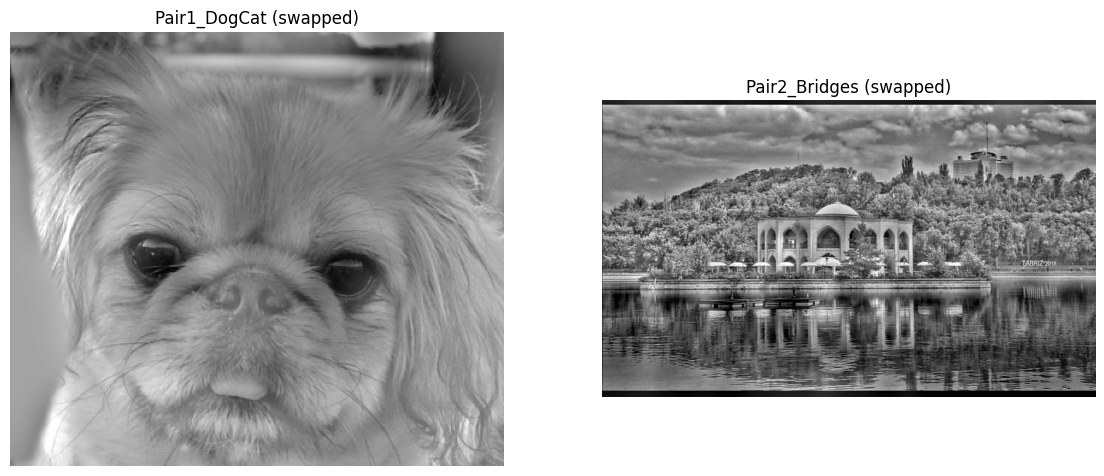

In [ ]:
hybrid_p3 = {}

for pair_name in pairs:
    G_near, L_near = pyramids[(pair_name, 'near')]
    G_far, L_far = pyramids[(pair_name, 'far')]
    L_hybrid = L_far[:4] + L_near[4:8]

    hybrid = reconstruct(L_hybrid)
    hybrid = np.clip(hybrid, 0, 255).astype(np.uint8)

    hybrid_p3[pair_name] = hybrid

    save_path = f'{OUT_DIR}/Part_3/{pair_name}_hybrid_swapped.png'
    cv2.imwrite(save_path, hybrid)

fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 7))

for ax, pair_name in zip(axes, pairs):
    ax.imshow(hybrid_p3[pair_name], cmap='gray')
    ax.set_title(pair_name + ' (swapped)')
    ax.axis('off')

plt.show()


<div dir="rtl" style="text-align: right;">
قسمت ۴ - ترکیب خطی روی همه‌ی ۸ سطح
</div>

In [ ]:
# ضریب near i: 1 - (i-1)/7    ضریب far: (i-1)/7

weights_near = [1 - i/7 for i in range(8)]
weights_far  = [i/7 for i in range(8)]
print(list(zip(range(1,9), weights_near, weights_far)))

[(1, 1.0, 0.0), (2, 0.8571428571428572, 0.14285714285714285), (3, 0.7142857142857143, 0.2857142857142857), (4, 0.5714285714285714, 0.42857142857142855), (5, 0.4285714285714286, 0.5714285714285714), (6, 0.2857142857142857, 0.7142857142857143), (7, 0.1428571428571429, 0.8571428571428571), (8, 0.0, 1.0)]


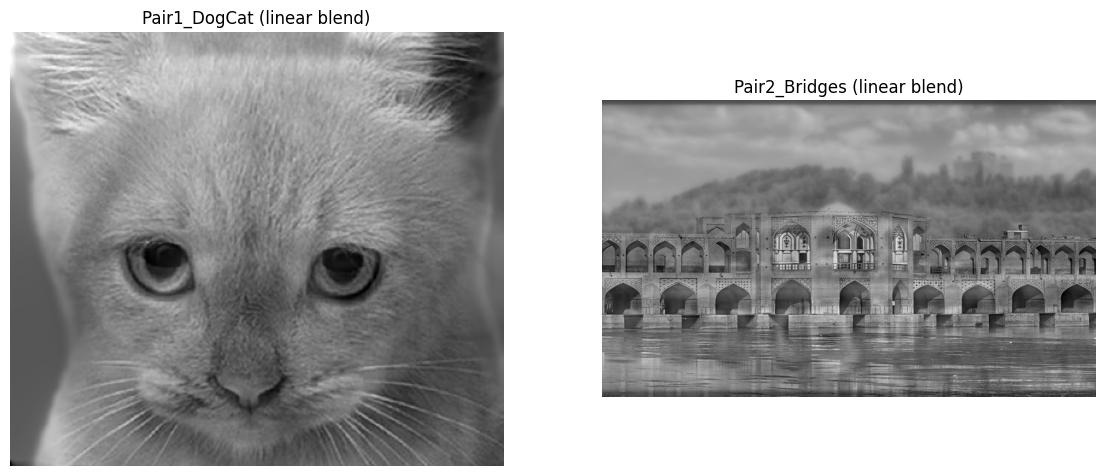

In [37]:
hybrid_p4 = {}
pyr_p4 = {}

for pair_name in pairs:
    G_near, L_near = pyramids[(pair_name, 'near')]
    G_far, L_far = pyramids[(pair_name, 'far')]

    L_blend = []

    for i in range(8):
        level = weights_near[i] * L_near[i] + weights_far[i] * L_far[i]
        L_blend.append(level)

    pyr_p4[pair_name] = L_blend

    hybrid = reconstruct(L_blend)
    hybrid = np.clip(hybrid, 0, 255).astype(np.uint8)

    hybrid_p4[pair_name] = hybrid

    cv2.imwrite(
        f'{OUT_DIR}/Part_4/{pair_name}_hybrid_blend.png',
        hybrid
    )

    tiled = tile_pyramid(L_blend)

    cv2.imwrite(
        f'{OUT_DIR}/Part_4/{pair_name}_blend_pyramid.png',
        tiled
    )


fig, axes = plt.subplots(
    1,
    len(pairs),
    figsize=(7 * len(pairs), 7)
)

for ax, pair_name in zip(axes, pairs):
    ax.imshow(hybrid_p4[pair_name], cmap='gray')
    ax.set_title(pair_name + ' (linear blend)')
    ax.axis('off')

plt.show()

Pair1_DogCat mean abs diff: 7.350023647050875 max abs diff: 41.0
Pair2_Bridges mean abs diff: 8.531653027823241 max abs diff: 55.0


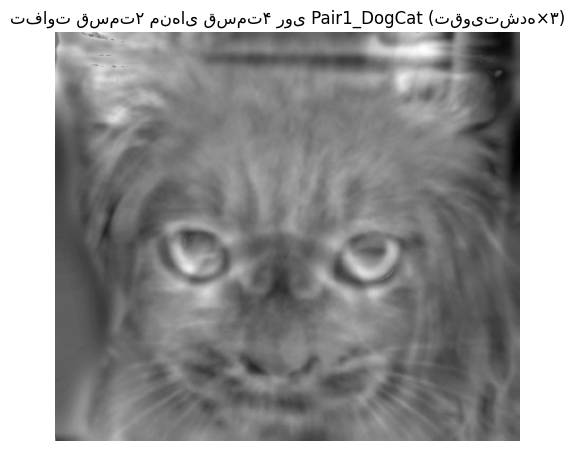

In [ ]:
for pair_name in pairs:
    diff = hybrid_p2[pair_name].astype(np.float64) - hybrid_p4[pair_name].astype(np.float64)
    print(pair_name, 'mean abs diff:', np.abs(diff).mean(), 'max abs diff:', np.abs(diff).max())

diff_vis = np.clip((hybrid_p2['Pair1_DogCat'].astype(np.float64) - hybrid_p4['Pair1_DogCat'].astype(np.float64))*3 + 128, 0, 255).astype(np.uint8)
plt.figure(figsize=(6,6))
plt.imshow(diff_vis, cmap='gray')
plt.title('تفاوت قسمت۲ منهای قسمت۴ روی Pair1_DogCat (تقویت‌شده×۳)')
plt.axis('off')
plt.show()

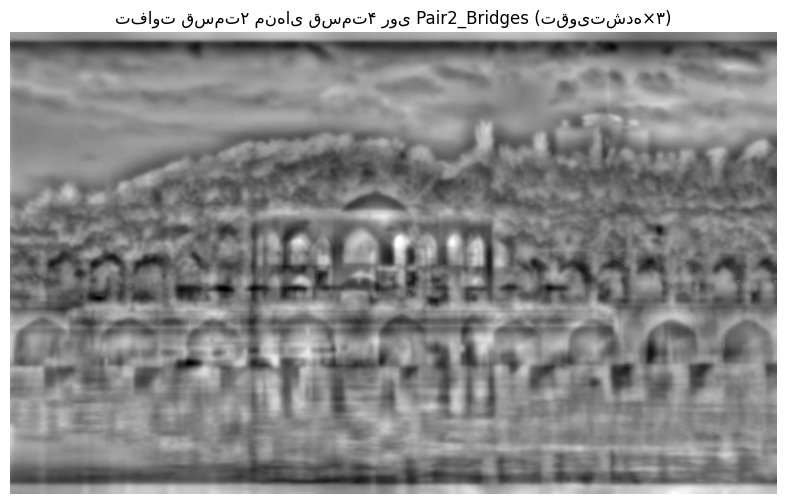

In [ ]:
diff_br = hybrid_p2['Pair2_Bridges'].astype(np.float64) - hybrid_p4['Pair2_Bridges'].astype(np.float64)
diff_br_vis = np.clip(diff_br*3 + 128, 0, 255).astype(np.uint8)
plt.figure(figsize=(10,6))
plt.imshow(diff_br_vis, cmap='gray')
plt.title('تفاوت قسمت۲ منهای قسمت۴ روی Pair2_Bridges (تقویت‌شده×۳)')
plt.axis('off')
plt.show()

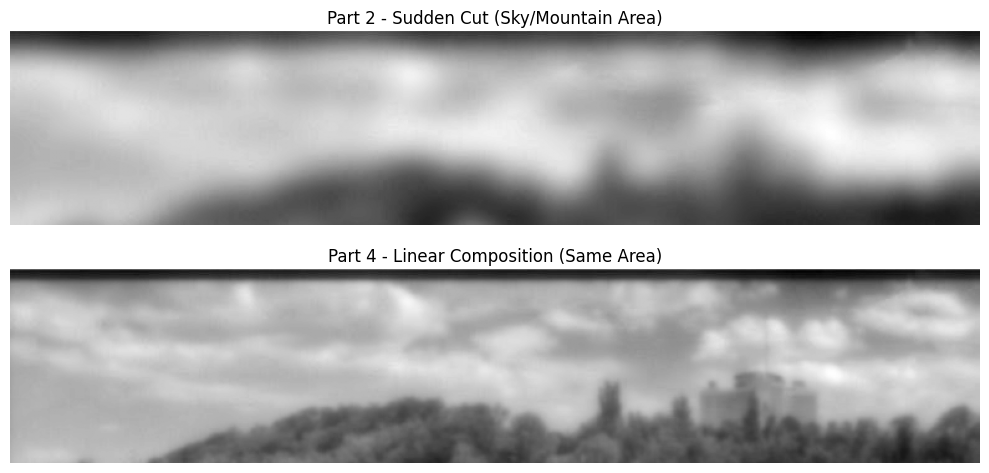

In [29]:
def top_third(im):
    h = im.shape[0]
    return im[0:h//3, :]

crop2 = top_third(hybrid_p2['Pair2_Bridges'])
crop4 = top_third(hybrid_p4['Pair2_Bridges'])

fig, axes = plt.subplots(2,1, figsize=(10,5))
axes[0].imshow(crop2, cmap='gray'); axes[0].set_title('Part 2 - Sudden Cut (Sky/Mountain Area)'); axes[0].axis('off')
axes[1].imshow(crop4, cmap='gray'); axes[1].set_title('Part 4 - Linear Composition (Same Area)'); axes[1].axis('off')
plt.tight_layout()
plt.show()